In [1]:
import tensorflow.compat.v1 as tf
try:
    tf.disable_v2_behavior()
except Exception:
    pass
print('TensorFlow', tf.__version__, 'running via compat.v1')


tf.compat.v1.disable_eager_execution()
tf.compat.v1.reset_default_graph()

/opt/anaconda3/envs/deep-learning/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Instructions for updating:
non-resource variables are not supported in the long term
TensorFlow 2.20.0 running via compat.v1


# Image Classification
In this project, you'll classify images from the [CIFAR-10 dataset](https://www.cs.toronto.edu/~kriz/cifar.html).  The dataset consists of airplanes, dogs, cats, and other objects. You'll preprocess the images, then train a convolutional neural network on all the samples. The images need to be normalized and the labels need to be one-hot encoded.  You'll get to apply what you learned and build a convolutional, max pooling, dropout, and fully connected layers.  At the end, you'll get to see your neural network's predictions on the sample images.
## Get the Data
Run the following cell to download the [CIFAR-10 dataset for python](https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz).

In [2]:
"""
Download and use CIFAR dataset
"""
from os.path import isfile, isdir
import os
from urllib.request import urlretrieve
from tqdm import tqdm
import problem_unittests as tests
import tarfile
import socket

cifar10_dataset_folder_path = 'cifar-10-batches-py'


def host_reachable(host='www.cs.toronto.edu', port=443, timeout=3):
    try:
        with socket.create_connection((host, port), timeout=timeout):
            return True
    except Exception:
        return False

# Allow CI or users to skip automatic downloads (useful offline or CI caching)
skip_env = os.environ.get('SKIP_CIFAR_DOWNLOAD', '0').lower() in ('1', 'true', 'yes')
if skip_env:
    print("SKIP_CIFAR_DOWNLOAD is set — skipping automatic CIFAR download. Make sure './cifar-10-batches-py' exists or provide a tarball 'cifar-10-python.tar.gz'.")

# If dataset already present, skip download
if isdir(cifar10_dataset_folder_path):
    print(f"Found existing dataset folder: {cifar10_dataset_folder_path}")
else:
    if skip_env:
        # Explicitly skipping download per env var
        pass
    else:
        # Check network connectivity before attempting big downloads
        if not host_reachable():
            print("Network appears to be unavailable. Cannot download CIFAR-10 automatically.")
            print("Please provide the dataset under './cifar-10-batches-py' or place the tarball 'cifar-10-python.tar.gz' in the working directory.")
        else:
            # Prefer using torchvision's downloader when available (more robust and handles mirrors)
            try:
                from torchvision.datasets import CIFAR10

                print("Downloading CIFAR-10 via torchvision...")
                CIFAR10(root='.', download=True)
            except Exception as e:
                print(f"torchvision download unavailable or failed: {e}")

                # Use Floyd's cifar-10 dataset if present
                floyd_cifar10_location = '/input/cifar-10/python.tar.gz'
                if isfile(floyd_cifar10_location):
                    tar_gz_path = floyd_cifar10_location
                else:
                    tar_gz_path = 'cifar-10-python.tar.gz'

                class DLProgress(tqdm):
                    last_block = 0

                    def hook(self, block_num=1, block_size=1, total_size=None):
                        self.total = total_size
                        self.update((block_num - self.last_block) * block_size)
                        self.last_block = block_num

                if not isfile(tar_gz_path):
                    with DLProgress(unit='B', unit_scale=True, miniters=1, desc='CIFAR-10 Dataset') as pbar:
                        urlretrieve(
                            'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz',
                            tar_gz_path,
                            pbar.hook)

                if not isdir(cifar10_dataset_folder_path):
                    with tarfile.open(tar_gz_path) as tar:
                        tar.extractall()
                        tar.close()


tests.test_folder_path(cifar10_dataset_folder_path)

Found existing dataset folder: cifar-10-batches-py
All files found!


## Explore the Data
The dataset is broken into batches to prevent your machine from running out of memory.  The CIFAR-10 dataset consists of 5 batches, named `data_batch_1`, `data_batch_2`, etc.. Each batch contains the labels and images that are one of the following:
* airplane
* automobile
* bird
* cat
* deer
* dog
* frog
* horse
* ship
* truck

Understanding a dataset is part of making predictions on the data.  Play around with the code cell below by changing the `batch_id` and `sample_id`. The `batch_id` is the id for a batch (1-5). The `sample_id` is the id for a image and label pair in the batch.

Ask yourself "What are all possible labels?", "What is the range of values for the image data?", "Are the labels in order or random?".  Answers to questions like these will help you preprocess the data and end up with better predictions.


Stats of batch 1:
Samples: 10000
Label Counts: {np.int64(0): np.int64(1005), np.int64(1): np.int64(974), np.int64(2): np.int64(1032), np.int64(3): np.int64(1016), np.int64(4): np.int64(999), np.int64(5): np.int64(937), np.int64(6): np.int64(1030), np.int64(7): np.int64(1001), np.int64(8): np.int64(1025), np.int64(9): np.int64(981)}
First 20 Labels: [6, 9, 9, 4, 1, 1, 2, 7, 8, 3, 4, 7, 7, 2, 9, 9, 9, 3, 2, 6]

Example of Image 5:
Image - Min Value: 0 Max Value: 252
Image - Shape: (32, 32, 3)
Label - Label Id: 1 Name: automobile


/Users/ajay/Workspace/Deep-Learning-Nano-Degree---Image-Classification-Project-2/helper.py:19: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch = pickle.load(file, encoding='latin1')


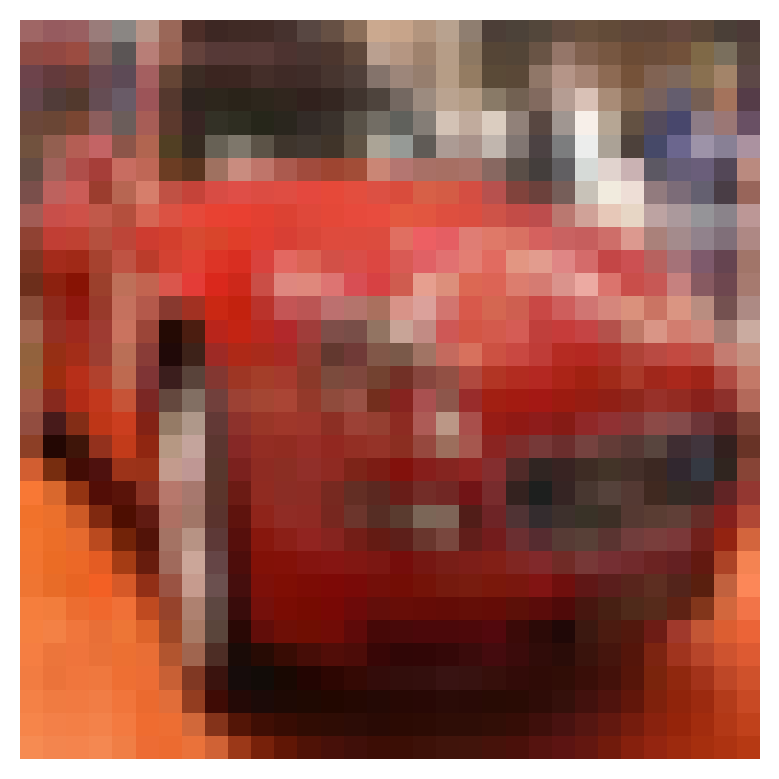

In [3]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import helper
import numpy as np

# Explore the dataset
batch_id = 1
sample_id = 5
helper.display_stats(cifar10_dataset_folder_path, batch_id, sample_id)

## Implement Preprocess Functions
### Normalize
In the cell below, implement the `normalize` function to take in image data, `x`, and return it as a normalized Numpy array. The values should be in the range of 0 to 1, inclusive.  The return object should be the same shape as `x`.

In [4]:
def normalize(x):
    """
    Normalize a list of sample image data in the range of 0 to 1
    : x: List of image data.  The image shape is (32, 32, 3)
    : return: Numpy array of normalize data
    """
    # TODO: Implement Function
    return x/255


"""
DON'T MODIFY ANYTHING IN THIS CELL THAT IS BELOW THIS LINE
"""
tests.test_normalize(normalize)

Tests Passed


### One-hot encode
Just like the previous code cell, you'll be implementing a function for preprocessing.  This time, you'll implement the `one_hot_encode` function. The input, `x`, are a list of labels.  Implement the function to return the list of labels as One-Hot encoded Numpy array.  The possible values for labels are 0 to 9. The one-hot encoding function should return the same encoding for each value between each call to `one_hot_encode`.  Make sure to save the map of encodings outside the function.

Hint: Don't reinvent the wheel.

In [5]:
def one_hot_encode(x):
    """
    One hot encode a list of sample labels. Return a one-hot encoded vector for each label.
    : x: List of sample Labels
    : return: Numpy array of one-hot encoded labels
    """
    # TODO: Implement Function
    return np.eye(10)[x]


"""
DON'T MODIFY ANYTHING IN THIS CELL THAT IS BELOW THIS LINE
"""
tests.test_one_hot_encode(one_hot_encode)

Tests Passed


### Randomize Data
As you saw from exploring the data above, the order of the samples are randomized.  It doesn't hurt to randomize it again, but you don't need to for this dataset.

## Preprocess all the data and save it
Running the code cell below will preprocess all the CIFAR-10 data and save it to file. The code below also uses 10% of the training data for validation.

In [6]:
"""
DON'T MODIFY ANYTHING IN THIS CELL
"""
# Preprocess Training, Validation, and Testing Data
helper.preprocess_and_save_data(cifar10_dataset_folder_path, normalize, one_hot_encode)

/Users/ajay/Workspace/Deep-Learning-Nano-Degree---Image-Classification-Project-2/helper.py:103: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch = pickle.load(file, encoding='latin1')


# Check Point
This is your first checkpoint.  If you ever decide to come back to this notebook or have to restart the notebook, you can start from here.  The preprocessed data has been saved to disk.

In [7]:
"""
DON'T MODIFY ANYTHING IN THIS CELL
"""
import pickle
import problem_unittests as tests
import helper

# Load the Preprocessed Validation data
valid_features, valid_labels = pickle.load(open('preprocess_validation.p', mode='rb'))

## Build the network
For the neural network, you'll build each layer into a function.  Most of the code you've seen has been outside of functions. To test your code more thoroughly, we require that you put each layer in a function.  This allows us to give you better feedback and test for simple mistakes using our unittests before you submit your project.

>**Note:** If you're finding it hard to dedicate enough time for this course each week, we've provided a small shortcut to this part of the project. In the next couple of problems, you'll have the option to use classes from the [TensorFlow Layers](https://www.tensorflow.org/api_docs/python/tf/layers) or [TensorFlow Layers (contrib)](https://www.tensorflow.org/api_guides/python/contrib.layers) packages to build each layer, except the layers you build in the "Convolutional and Max Pooling Layer" section.  TF Layers is similar to Keras's and TFLearn's abstraction to layers, so it's easy to pickup.

>However, if you would like to get the most out of this course, try to solve all the problems _without_ using anything from the TF Layers packages. You **can** still use classes from other packages that happen to have the same name as ones you find in TF Layers! For example, instead of using the TF Layers version of the `conv2d` class, [tf.layers.conv2d](https://www.tensorflow.org/api_docs/python/tf/layers/conv2d), you would want to use the TF Neural Network version of `conv2d`, [tf.nn.conv2d](https://www.tensorflow.org/api_docs/python/tf/nn/conv2d). 

Let's begin!

### Input
The neural network needs to read the image data, one-hot encoded labels, and dropout keep probability. Implement the following functions
* Implement `neural_net_image_input`
 * Return a [TF Placeholder](https://www.tensorflow.org/api_docs/python/tf/placeholder)
 * Set the shape using `image_shape` with batch size set to `None`.
 * Name the TensorFlow placeholder "x" using the TensorFlow `name` parameter in the [TF Placeholder](https://www.tensorflow.org/api_docs/python/tf/placeholder).
* Implement `neural_net_label_input`
 * Return a [TF Placeholder](https://www.tensorflow.org/api_docs/python/tf/placeholder)
 * Set the shape using `n_classes` with batch size set to `None`.
 * Name the TensorFlow placeholder "y" using the TensorFlow `name` parameter in the [TF Placeholder](https://www.tensorflow.org/api_docs/python/tf/placeholder).
* Implement `neural_net_keep_prob_input`
 * Return a [TF Placeholder](https://www.tensorflow.org/api_docs/python/tf/placeholder) for dropout keep probability.
 * Name the TensorFlow placeholder "keep_prob" using the TensorFlow `name` parameter in the [TF Placeholder](https://www.tensorflow.org/api_docs/python/tf/placeholder).

These names will be used at the end of the project to load your saved model.

Note: `None` for shapes in TensorFlow allow for a dynamic size.

In [8]:
import tensorflow as tf
import warnings


tf.compat.v1.disable_eager_execution()



def neural_net_image_input(image_shape):

    return tf.compat.v1.placeholder(
        tf.float32,
        shape=[None, image_shape[0], image_shape[1], image_shape[2]],
        name='x'
    )


def neural_net_label_input(n_classes):

    return tf.compat.v1.placeholder(
        tf.float32,
        shape=[None, n_classes],
        name='y'
    )

def neural_net_keep_prob_input():

    return tf.compat.v1.placeholder(
        tf.float32,
        name='keep_prob'
    )


"""
DON'T MODIFY ANYTHING IN THIS CELL THAT IS BELOW THIS LINE
"""
# Debug info before attempting to reset the graph
print("[debug] tf object:", tf)
print("[debug] hasattr(tf,'compat'):", hasattr(tf,'compat'))
try:
    print("[debug] tf.__version__:", tf.__version__)
except Exception:
    print("[debug] tf.__version__ not available")
print("[debug] hasattr(tf,'reset_default_graph'):", hasattr(tf,'reset_default_graph'))
if hasattr(tf, 'compat'):
    print("[debug] has compat.v1:", hasattr(tf.compat, 'v1'))
    try:
        print("[debug] compat.v1 has reset_default_graph:", hasattr(tf.compat.v1, 'reset_default_graph'))
    except Exception:
        print("[debug] cannot access tf.compat.v1 attributes")

# Reset the graph only via compat.v1.reset_default_graph if available; otherwise skip
if hasattr(tf, 'compat') and hasattr(tf.compat, 'v1') and hasattr(tf.compat.v1, 'reset_default_graph'):
    try:
        tf.compat.v1.reset_default_graph()
    except Exception as e:
        warnings.warn(f"Could not reset default graph via compat.v1: {e}")
else:
    warnings.warn("compat.v1.reset_default_graph not available — skipping graph reset.")

# Run tests for the input helper functions
tests.test_nn_image_inputs(neural_net_image_input)
tests.test_nn_label_inputs(neural_net_label_input)
tests.test_nn_keep_prob_inputs(neural_net_keep_prob_input)

[debug] tf object: <module 'tensorflow' from '/opt/anaconda3/envs/deep-learning/lib/python3.11/site-packages/tensorflow/__init__.py'>
[debug] hasattr(tf,'compat'): True
[debug] tf.__version__: 2.20.0
[debug] hasattr(tf,'reset_default_graph'): False
[debug] has compat.v1: True
[debug] compat.v1 has reset_default_graph: True
Image Input Tests Passed.
Label Input Tests Passed.
Keep Prob Tests Passed.


In [9]:
# Quick TF import and compatibility check (separate test cell)
import tensorflow as tf
import sys
print('tf module:', tf)
print('tf version:', getattr(tf, '__version__', 'unknown'))
print('has compat:', hasattr(tf, 'compat'))
if hasattr(tf, 'compat'):
    print('has compat.v1:', hasattr(tf.compat, 'v1'))
    try:
        print('compat.v1 has reset_default_graph:', hasattr(tf.compat.v1, 'reset_default_graph'))
    except Exception as e:
        print('could not access tf.compat.v1:', e)

# Show whether placeholders and reset are present on top-level module
print('has placeholder:', hasattr(tf, 'placeholder'))
print('has reset_default_graph:', hasattr(tf, 'reset_default_graph'))

# Try to call compat reset (safe)
try:
    if hasattr(tf, 'compat') and hasattr(tf.compat, 'v1') and hasattr(tf.compat.v1, 'reset_default_graph'):
        tf.compat.v1.reset_default_graph()
        print('compat.v1.reset_default_graph() called successfully')
    else:
        print('compat.v1.reset_default_graph not available')
except Exception as e:
    print('calling compat.v1.reset_default_graph failed:', e)


tf module: <module 'tensorflow' from '/opt/anaconda3/envs/deep-learning/lib/python3.11/site-packages/tensorflow/__init__.py'>
tf version: 2.20.0
has compat: True
has compat.v1: True
compat.v1 has reset_default_graph: True
has placeholder: False
has reset_default_graph: False
compat.v1.reset_default_graph() called successfully


In [10]:
# Sanity checks for TF2 migration
import tensorflow as tf
import inspect

print('tf has placeholder:', hasattr(tf, 'placeholder'))
try:
    src = inspect.getsource(neural_net_image_input)
    print('\nneural_net_image_input source:\n', src)
    print("contains 'placeholder'?:", 'placeholder' in src)
except Exception as e:
    print('Could not inspect neural_net_image_input:', e)

try:
    print('neural_net_image_input((32,32,3)) ->', neural_net_image_input((32,32,3)))
    print('neural_net_keep_prob_input ->', neural_net_keep_prob_input())
except Exception as e:
    print('Error when calling input helpers:', e)

tf has placeholder: False

neural_net_image_input source:
 def neural_net_image_input(image_shape):

    return tf.compat.v1.placeholder(
        tf.float32,
        shape=[None, image_shape[0], image_shape[1], image_shape[2]],
        name='x'
    )

contains 'placeholder'?: True
neural_net_image_input((32,32,3)) -> Tensor("x:0", shape=(?, 32, 32, 3), dtype=float32)
neural_net_keep_prob_input -> Tensor("keep_prob:0", dtype=float32)


In [11]:
# Utility: train one batch using Keras model

def train_neural_network(model, keep_probability, feature_batch, label_batch, epochs=1):
    """
    Perform a single training step (or multiple via epochs) using Keras model.fit
    :param model: tf.keras.Model
    :param keep_probability: Not used directly (Dropout is handled inside model)
    :param feature_batch: numpy array of features
    :param label_batch: numpy array of labels
    :param epochs: number of passes
    """
    model.fit(feature_batch, label_batch, epochs=epochs, batch_size=feature_batch.shape[0], verbose=0)


# Utility: print stats using Keras evaluation

def print_stats(model, feature_batch, label_batch):
    """Print training loss/accuracy and validation accuracy"""
    train_loss, train_acc = model.evaluate(feature_batch, label_batch, verbose=0)
    try:
        valid_loss, valid_acc = model.evaluate(valid_features, valid_labels, verbose=0)
    except Exception:
        valid_loss, valid_acc = None, None
    print(f"Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Valid Acc: {valid_acc}")

### Convolution and Max Pooling Layer
Convolution layers have a lot of success with images. For this code cell, you should implement the function `conv2d_maxpool` to apply convolution then max pooling:
* Create the weight and bias using `conv_ksize`, `conv_num_outputs` and the shape of `x_tensor`.
* Apply a convolution to `x_tensor` using weight and `conv_strides`.
 * We recommend you use same padding, but you're welcome to use any padding.
* Add bias
* Add a nonlinear activation to the convolution.
* Apply Max Pooling using `pool_ksize` and `pool_strides`.
 * We recommend you use same padding, but you're welcome to use any padding.

**Note:** You **can't** use [TensorFlow Layers](https://www.tensorflow.org/api_docs/python/tf/layers) or [TensorFlow Layers (contrib)](https://www.tensorflow.org/api_guides/python/contrib.layers) for **this** layer, but you can still use TensorFlow's [Neural Network](https://www.tensorflow.org/api_docs/python/tf/nn) package. You may still use the shortcut option for all the **other** layers.

In [12]:
from tensorflow.keras import layers

def conv2d_maxpool(x_tensor, conv_num_outputs, conv_ksize, conv_strides, pool_ksize, pool_strides):
    """
    Apply convolution then max pooling to x_tensor using Keras layers
    :param x_tensor: tf.Tensor or Keras Tensor
    :param conv_num_outputs: Number of outputs for the convolutional layer
    :param conv_ksize: kernal size 2-D Tuple for the convolutional layer
    :param conv_strides: Stride 2-D Tuple for convolution
    :param pool_ksize: kernal size 2-D Tuple for pool
    :param pool_strides: Stride 2-D Tuple for pool
    : return: A tensor that represents convolution and max pooling of x_tensor
    """
    # Use Keras Conv2D and MaxPool2D for TF2 compatibility
    conv = layers.Conv2D(filters=conv_num_outputs,
                         kernel_size=conv_ksize,
                         strides=conv_strides,
                         padding='same',
                         activation='relu')(x_tensor)

    pool = layers.MaxPool2D(pool_size=pool_ksize, strides=pool_strides, padding='same')(conv)

    return pool


"""
DON'T MODIFY ANYTHING IN THIS CELL THAT IS BELOW THIS LINE
"""
tests.test_con_pool(conv2d_maxpool)

Tests Passed


### Flatten Layer
Implement the `flatten` function to change the dimension of `x_tensor` from a 4-D tensor to a 2-D tensor.  The output should be the shape (*Batch Size*, *Flattened Image Size*). Shortcut option: you can use classes from the [TensorFlow Layers](https://www.tensorflow.org/api_docs/python/tf/layers) or [TensorFlow Layers (contrib)](https://www.tensorflow.org/api_guides/python/contrib.layers) packages for this layer. For more of a challenge, only use other TensorFlow packages.

In [13]:
def flatten(x_tensor):
    """
    Flatten a tensor into a 2D tensor
    """
    shape = x_tensor.get_shape().as_list()
    dim = shape[1] * shape[2] * shape[3]
    return tf.reshape(x_tensor, [-1, dim])

tests.test_flatten(flatten)

Tests Passed


### Fully-Connected Layer
Implement the `fully_conn` function to apply a fully connected layer to `x_tensor` with the shape (*Batch Size*, *num_outputs*). Shortcut option: you can use classes from the [TensorFlow Layers](https://www.tensorflow.org/api_docs/python/tf/layers) or [TensorFlow Layers (contrib)](https://www.tensorflow.org/api_guides/python/contrib.layers) packages for this layer. For more of a challenge, only use other TensorFlow packages.

In [14]:
def fully_conn(x_tensor, num_outputs):
    """
    Apply a fully connected layer to x_tensor using Keras Dense
    : x_tensor: A 2-D tensor where the first dimension is batch size.
    : num_outputs: The number of output that the new tensor should be.
    : return: A 2-D tensor where the second dimension is num_outputs.
    """
    from tensorflow.keras import layers
    dense = layers.Dense(units=num_outputs, activation='relu')(x_tensor)
    return dense



tests.test_fully_conn(fully_conn)

Tests Passed


### Output Layer
Implement the `output` function to apply a fully connected layer to `x_tensor` with the shape (*Batch Size*, *num_outputs*). Shortcut option: you can use classes from the [TensorFlow Layers](https://www.tensorflow.org/api_docs/python/tf/layers) or [TensorFlow Layers (contrib)](https://www.tensorflow.org/api_guides/python/contrib.layers) packages for this layer. For more of a challenge, only use other TensorFlow packages.

**Note:** Activation, softmax, or cross entropy should **not** be applied to this.

In [15]:
def output(x_tensor, num_outputs):
    """
    Apply an output layer to x_tensor using Keras Dense (no activation)
    : x_tensor: A 2-D tensor where the first dimension is batch size.
    : num_outputs: The number of output that the new tensor should be.
    : return: A 2-D tensor where the second dimension is num_outputs.
    """
    from tensorflow.keras import layers
    logits = layers.Dense(units=num_outputs, activation=None, name='logits')(x_tensor)
    return logits


"""
DON'T MODIFY ANYTHING IN THIS CELL THAT IS BELOW THIS LINE
"""
tests.test_output(output)

Tests Passed


In [16]:
def conv_net(x, keep_prob=None):
    """
    Create a convolutional neural network using the layer functions above and return logits.
    :param x: input Keras tensor
    :param keep_prob: unused (kept for API compatibility)
    :return: logits tensor
    """
    # Block 1
    conv1 = conv2d_maxpool(x, conv_num_outputs=32, conv_ksize=(3, 3), conv_strides=(1, 1), pool_ksize=(2, 2), pool_strides=(2, 2))
    # Block 2
    conv2 = conv2d_maxpool(conv1, conv_num_outputs=64, conv_ksize=(3, 3), conv_strides=(1, 1), pool_ksize=(2, 2), pool_strides=(2, 2))
    # Flatten
    flat = flatten(conv2)
    # Fully connected
    fc = fully_conn(flat, 512)
    # Dropout (fixed rate for TF2 compatibility)
    from tensorflow.keras import layers
    dropout = layers.Dropout(rate=0.5)(fc)
    # Output logits
    logits = output(dropout, 10)
    return logits


"""
DON'T MODIFY ANYTHING IN THIS CELL THAT IS BELOW THIS LINE
"""
# Test conv_net implementation
tests.test_conv_net(conv_net)

Neural Network Built!


### Create Convolutional Model
Implement the function `conv_net` to create a convolutional neural network model. The function takes in a batch of images, `x`, and outputs logits.  Use the layers you created above to create this model:

* Apply 1, 2, or 3 Convolution and Max Pool layers
* Apply a Flatten Layer
* Apply 1, 2, or 3 Fully Connected Layers
* Apply an Output Layer
* Return the output
* Apply [TensorFlow's Dropout](https://www.tensorflow.org/api_docs/python/tf/nn/dropout) to one or more layers in the model using `keep_prob`. 

In [17]:
def conv_net(x, keep_prob):
    """
    Create a convolutional neural network model
    : x: Placeholder tensor that holds image data.
    : keep_prob: Placeholder tensor that hold dropout keep probability.
    : return: Tensor that represents logits
    """
    # TODO: Apply 1, 2, or 3 Convolution and Max Pool layers
    #    Play around with different number of outputs, kernel size and stride
    # Function Definition from Above:
    #    conv2d_maxpool(x_tensor, conv_num_outputs, conv_ksize, conv_strides, pool_ksize, pool_strides)
    conv = conv2d_maxpool(x, 32, (8,8),(1,1),(2,2),(2,2) )
    conv = conv2d_maxpool(conv, 64, (4,4),(1,1),(2,2),(2,2) )
    conv = conv2d_maxpool(conv, 128, (2,2),(1,1),(2,2),(2,2) )
    
    

    # TODO: Apply a Flatten Layer
    # Function Definition from Above:
    #   flatten(x_tensor)
    flattened = flatten(conv)

    # TODO: Apply 1, 2, or 3 Fully Connected Layers
    #    Play around with different number of outputs
    # Function Definition from Above:
    #   fully_conn(x_tensor, num_outputs)
    full_conn = fully_conn(flattened,128)
    full_conn = fully_conn(full_conn,64)
    full_conn = tf.nn.dropout(full_conn,keep_prob)
    
    # TODO: Apply an Output Layer
    #    Set this to the number of classes
    # Function Definition from Above:
    #   output(x_tensor, num_outputs)
        
    # TODO: return output
    return output(full_conn,10)


"""
DON'T MODIFY ANYTHING IN THIS CELL THAT IS BELOW THIS LINE
"""

##############################
## Build the Neural Network ##
##############################

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

# Remove previous weights, bias, inputs, etc..
tf.reset_default_graph()

# Inputs
x = neural_net_image_input((32, 32, 3))
y = neural_net_label_input(10)
keep_prob = neural_net_keep_prob_input()

# Model
logits = conv_net(x, keep_prob)

# Name logits Tensor, so that is can be loaded from disk after training
logits = tf.identity(logits, name='logits')

# Loss and Optimizer
cost = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(logits=logits, labels=y))
optimizer = tf.train.AdamOptimizer().minimize(cost)

# Accuracy
correct_pred = tf.equal(tf.argmax(logits, 1), tf.argmax(y, 1))
accuracy = tf.reduce_mean(tf.cast(correct_pred, tf.float32), name='accuracy')

tests.test_conv_net(conv_net)

Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.
Instructions for updating:

Future major versions of TensorFlow will allow gradients to flow
into the labels input on backprop by default.

See `tf.nn.softmax_cross_entropy_with_logits_v2`.

Neural Network Built!


## Train the Neural Network
### Single Optimization
Implement the function `train_neural_network` to do a single optimization.  The optimization should use `optimizer` to optimize in `session` with a `feed_dict` of the following:
* `x` for image input
* `y` for labels
* `keep_prob` for keep probability for dropout

This function will be called for each batch, so `tf.global_variables_initializer()` has already been called.

Note: Nothing needs to be returned. This function is only optimizing the neural network.

In [18]:
def train_neural_network(session, optimizer, keep_probability, feature_batch, label_batch):
    """
    Optimize the session on a batch of images and labels
    : session: Current TensorFlow session
    : optimizer: TensorFlow optimizer function
    : keep_probability: keep probability
    : feature_batch: Batch of Numpy image data
    : label_batch: Batch of Numpy label data
    """
    # TODO: Implement Function
    session.run(optimizer, feed_dict={
        x: feature_batch,
        y: label_batch,
        keep_prob: keep_probability
    })



"""
DON'T MODIFY ANYTHING IN THIS CELL THAT IS BELOW THIS LINE
"""
tests.test_train_nn(train_neural_network)

Tests Passed


### Show Stats
Implement the function `print_stats` to print loss and validation accuracy.  Use the global variables `valid_features` and `valid_labels` to calculate validation accuracy.  Use a keep probability of `1.0` to calculate the loss and validation accuracy.

In [19]:
def print_stats(session, feature_batch, label_batch, cost, accuracy):
    """
    Print information about loss and validation accuracy
    : session: Current TensorFlow session
    : feature_batch: Batch of Numpy image data
    : label_batch: Batch of Numpy label data
    : cost: TensorFlow cost function
    : accuracy: TensorFlow accuracy function
    """
    # TODO: Implement Function
    loss = session.run(cost, feed_dict={
        x: feature_batch,
        y: label_batch,
        keep_prob: 1.0
    })
    
    train_accuracy = session.run(accuracy, feed_dict={
        x: feature_batch,
        y: label_batch,
        keep_prob: 1.0
    })
    
    valid_accuracy = session.run(accuracy, feed_dict={
        x: valid_features,
        y: valid_labels,
        keep_prob: 1.0
    })
    
    print('Loss: {:10.5f} , Training Accuracy: {:.5f}, Validation Accuracy: {:.5f}'
          .format( loss, train_accuracy, valid_accuracy))

### Hyperparameters
Tune the following parameters:
* Set `epochs` to the number of iterations until the network stops learning or start overfitting
* Set `batch_size` to the highest number that your machine has memory for.  Most people set them to common sizes of memory:
 * 64
 * 128
 * 256
 * ...
* Set `keep_probability` to the probability of keeping a node using dropout

In [20]:
# TODO: Tune Parameters
epochs = 3
batch_size = 1024
keep_probability = 0.8

### Train on a Single CIFAR-10 Batch
Instead of training the neural network on all the CIFAR-10 batches of data, let's use a single batch. This should save time while you iterate on the model to get a better accuracy.  Once the final validation accuracy is 50% or greater, run the model on all the data in the next section.

In [21]:

# Set your hyperparameter
keep_probability_amount = 0.5
# 1. Define the Session
with tf.Session() as sess:
    # 2. Initialize variables
    sess.run(tf.global_variables_initializer())
    
    print('Checking the Training on a Single Batch...')
    for epoch in range(epochs):
        batch_i = 1
        for batch_features, batch_labels in helper.load_preprocess_training_batch(batch_i, batch_size):
            # 3. Pass 'sess' and the 'optimizer'
            train_neural_network(sess, optimizer, keep_probability_amount, batch_features, batch_labels)
            
        print('Epoch {:>2}, CIFAR-10 Batch {}:  '.format(epoch + 1, batch_i), end='')
        print_stats(sess, batch_features, batch_labels,cost, accuracy) # Note: print_stats usually needs the session too

I0000 00:00:1766624235.869821  840776 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


Checking the Training on a Single Batch...
Epoch  1, CIFAR-10 Batch 1:  Loss:    2.21352 , Training Accuracy: 0.20173, Validation Accuracy: 0.17660
Epoch  2, CIFAR-10 Batch 1:  Loss:    2.09100 , Training Accuracy: 0.25000, Validation Accuracy: 0.23380
Epoch  3, CIFAR-10 Batch 1:  Loss:    1.96998 , Training Accuracy: 0.32921, Validation Accuracy: 0.32560


### Fully Train the Model
Now that you got a good accuracy with a single CIFAR-10 batch, try it with all five batches.

In [22]:
save_model_path = './image_classification'

print('Training...')

# Build Saver AFTER graph is fully defined
saver = tf.compat.v1.train.Saver()

with tf.compat.v1.Session() as sess:
    # Initialize variables
    sess.run(tf.compat.v1.global_variables_initializer())

    # Training cycle
    for epoch in range(epochs):
        n_batches = 5
        for batch_i in range(1, n_batches + 1):
            for batch_features, batch_labels in helper.load_preprocess_training_batch(
                batch_i, batch_size
            ):
                train_neural_network(
                    sess,
                    optimizer,
                    keep_probability_amount,
                    batch_features,
                    batch_labels
                )

            print(
                'Epoch {:>2}, CIFAR-10 Batch {}:  '.format(epoch + 1, batch_i),
                end=''
            )
            print_stats(
                sess,
                batch_features,
                batch_labels,
                cost,
                accuracy
            )

    # Save model ONCE
    saver.save(sess, save_model_path)
    print('Model Saved')


Training...
Epoch  1, CIFAR-10 Batch 1:  Loss:    2.20486 , Training Accuracy: 0.23391, Validation Accuracy: 0.23100
Epoch  1, CIFAR-10 Batch 2:  Loss:    2.14318 , Training Accuracy: 0.26361, Validation Accuracy: 0.26500
Epoch  1, CIFAR-10 Batch 3:  Loss:    1.99196 , Training Accuracy: 0.28589, Validation Accuracy: 0.30500
Epoch  1, CIFAR-10 Batch 4:  Loss:    1.88603 , Training Accuracy: 0.35025, Validation Accuracy: 0.33740
Epoch  1, CIFAR-10 Batch 5:  Loss:    1.83400 , Training Accuracy: 0.33911, Validation Accuracy: 0.35240
Epoch  2, CIFAR-10 Batch 1:  Loss:    1.74415 , Training Accuracy: 0.40099, Validation Accuracy: 0.40060
Epoch  2, CIFAR-10 Batch 2:  Loss:    1.71478 , Training Accuracy: 0.39851, Validation Accuracy: 0.39200
Epoch  2, CIFAR-10 Batch 3:  Loss:    1.62017 , Training Accuracy: 0.42822, Validation Accuracy: 0.41000
Epoch  2, CIFAR-10 Batch 4:  Loss:    1.61484 , Training Accuracy: 0.40099, Validation Accuracy: 0.40900
Epoch  2, CIFAR-10 Batch 5:  Loss:    1.588

# Checkpoint
The model has been saved to disk.
## Test Model
Test your model against the test dataset.  This will be your final accuracy. You should have an accuracy greater than 50%. If you don't, keep tweaking the model architecture and parameters.

In [23]:
# TF1-style testing function using checkpoints (Udacity compatible)

import tensorflow as tf
import pickle
import helper
import random
import os



def test_model():
    tf.compat.v1.reset_default_graph()   # ⭐ THIS IS THE FIX ⭐

    # Rebuild graph inputs
    x = tf.compat.v1.placeholder(tf.float32, [None, 32, 32, 3], name='x')
    y = tf.compat.v1.placeholder(tf.float32, [None, 10], name='y')
    keep_prob = tf.compat.v1.placeholder(tf.float32, name='keep_prob')

    logits = conv_net(x, keep_prob)

    correct_pred = tf.equal(tf.argmax(logits, 1), tf.argmax(y, 1))
    accuracy = tf.reduce_mean(tf.cast(correct_pred, tf.float32))

    saver = tf.compat.v1.train.Saver()

    with tf.compat.v1.Session() as sess:
        saver.restore(sess, save_model_path)
        print("Model restored successfully.")

        # Evaluate in batches
        test_acc_total = 0.0
        test_batch_count = 0

        for test_feature_batch, test_label_batch in helper.batch_features_labels(
            test_features, test_labels, batch_size
        ):
            batch_acc = sess.run(
                accuracy,
                feed_dict={
                    x: test_feature_batch,
                    y: test_label_batch,
                    keep_prob: 1.0
                }
            )
            test_acc_total += batch_acc
            test_batch_count += 1

        print('Testing Accuracy: {}'.format(
            test_acc_total / max(1, test_batch_count)
        ))

        # Random sample predictions
        random_features, random_labels = tuple(
            zip(*random.sample(list(zip(test_features, test_labels)), n_samples))
        )

        preds = sess.run(
            tf.nn.softmax(logits),
            feed_dict={x: random_features, keep_prob: 1.0}
        )

        pred_topk = tf.math.top_k(preds, k=top_n_predictions)
        helper.display_image_predictions(
            random_features, random_labels, pred_topk
        )



## Why 50-70% Accuracy?
You might be wondering why you can't get an accuracy any higher. First things first, 50% isn't bad for a simple CNN.  Pure guessing would get you 10% accuracy. However, you might notice people are getting scores [well above 70%](http://rodrigob.github.io/are_we_there_yet/build/classification_datasets_results.html#43494641522d3130).  That's because we haven't taught you all there is to know about neural networks. We still need to cover a few more techniques.
## Submitting This Project
When submitting this project, make sure to run all the cells before saving the notebook.  Save the notebook file as "dlnd_image_classification.ipynb" and save it as a HTML file under "File" -> "Download as".  Include the "helper.py" and "problem_unittests.py" files in your submission.

In [24]:
# Run TF1-based test
test_model()


INFO:tensorflow:Restoring parameters from ./image_classification


2025-12-24 18:58:08.791414: W tensorflow/core/framework/op_kernel.cc:1855] OP_REQUIRES failed at save_restore_v2_ops.cc:233 : NOT_FOUND: Key conv2d_10/bias not found in checkpoint
2025-12-24 18:58:08.791430: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: NOT_FOUND: Key conv2d_10/bias not found in checkpoint
	 [[{{node save/RestoreV2}}]]


NotFoundError: Restoring from checkpoint failed. This is most likely due to a Variable name or other graph key that is missing from the checkpoint. Please ensure that you have not altered the graph expected based on the checkpoint. Original error:

Graph execution error:

Detected at node 'save/RestoreV2' defined at (most recent call last):
    File "<frozen runpy>", line 198, in _run_module_as_main
    File "<frozen runpy>", line 88, in _run_code
    File "/opt/anaconda3/envs/deep-learning/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    File "/opt/anaconda3/envs/deep-learning/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    File "/opt/anaconda3/envs/deep-learning/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start
    File "/opt/anaconda3/envs/deep-learning/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
    File "/opt/anaconda3/envs/deep-learning/lib/python